# 04 · Diagnóstico de Cáncer — Evaluación Final en Test

Evalúa los 4 modelos entrenados sobre el **conjunto de test**, aplicando
los umbrales fijados en validación. Ningún parámetro se re-ajusta aquí.

> **Nota metodológica:** AUC-ROC → probabilidades crudas (`predict_proba` /
> `sigmoid(logits)`). Precisión / Recall / F1 → predicciones binarias con
> el umbral de validación. Usar `predict` para AUC es un error frecuente.

## 01 · Configuración del entorno

In [1]:
# %matplotlib inline usa el backend de Jupyter (no Agg ni Tk/Qt)
# Debe ir ANTES de cualquier import de pyplot
%matplotlib inline

import os, site as _site
# Registra DLLs de torch antes de cualquier import (fix WinError 1114)
for _sp in _site.getsitepackages():
    _td = os.path.join(_sp, "torch", "lib")
    if os.path.isdir(_td) and hasattr(os, "add_dll_directory"):
        os.add_dll_directory(_td)
        break

os.environ['OMP_NUM_THREADS']      = '1'
os.environ['MKL_NUM_THREADS']      = '1'
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'
os.environ['OPENBLAS_NUM_THREADS'] = '1'

import sys, pathlib, json, pickle, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.metrics import (
    precision_score, recall_score, f1_score, roc_auc_score,
    roc_curve, precision_recall_curve, confusion_matrix,
)
warnings.filterwarnings("ignore")

ROOT       = pathlib.Path(r"c:\Users\victo\OneDrive\Escritorio\CASO_3_IA_(cancer)\Prediccion_de_cancer")
PROC_DIR   = ROOT / "outputs" / "processed"
MODELS_DIR = ROOT / "outputs" / "models"
FIGS_DIR   = ROOT / "outputs" / "figures"
sys.path.insert(0, str(ROOT))

import matplotlib
print(f"Entorno OK  |  matplotlib backend: {matplotlib.get_backend()}")

Entorno OK  |  matplotlib backend: module://matplotlib_inline.backend_inline


## 02 · Carga de datos, modelos y umbrales

In [2]:
# Arrays de test — nunca vistos durante entrenamiento ni optimización de umbral
X_test = np.load(PROC_DIR / "X_test.npy")
y_test = np.load(PROC_DIR / "y_test.npy")

with open(PROC_DIR / "meta.json") as f:
    meta = json.load(f)
FEATURE_NAMES = meta["features"]

print(f"Test: {X_test.shape}  |  positivos = {int(y_test.sum())} ({y_test.mean()*100:.1f}%)")

Test: (7501, 19)  |  positivos = 1447 (19.3%)


In [3]:
# Umbrales optimizados en validación — se aplican tal cual, sin reajuste
with open(MODELS_DIR / "thresholds.json") as f:
    thresholds = json.load(f)
print("Umbrales (val):", {k: round(v, 3) for k, v in thresholds.items()})

Umbrales (val): {'LR': 0.62, 'RF': 0.435, 'XGBoost': 0.555, 'MLP': 0.65}


In [4]:
# Modelos sklearn
with open(MODELS_DIR / "lr_model.pkl",  "rb") as f: lr_model  = pickle.load(f)
with open(MODELS_DIR / "rf_model.pkl",  "rb") as f: rf_model  = pickle.load(f)
with open(MODELS_DIR / "xgb_model.pkl", "rb") as f: xgb_model = pickle.load(f)
print("Modelos sklearn cargados")

Modelos sklearn cargados


In [5]:
# MLP — reconstruye arquitectura y carga pesos guardados
import torch
import torch.nn as nn
torch.set_num_threads(1)
torch.set_num_interop_threads(1)

with open(MODELS_DIR / "mlp_config.json") as f:
    cfg = json.load(f)

class MLP(nn.Module):
    def __init__(self, input_dim, hidden_dims, dropout):
        super().__init__()
        layers, prev = [], input_dim
        for h in hidden_dims:
            layers += [nn.Linear(prev, h), nn.BatchNorm1d(h), nn.ReLU(), nn.Dropout(dropout)]
            prev = h
        layers.append(nn.Linear(prev, 1))
        self.net = nn.Sequential(*layers)
    def forward(self, x):
        return self.net(x).squeeze(1)

mlp_model = MLP(cfg["input_dim"], cfg["hidden_dims"], cfg["dropout"])
mlp_model.load_state_dict(
    torch.load(MODELS_DIR / "mlp_weights.pt", map_location="cpu", weights_only=True)
)
mlp_model.eval()
print("MLP cargado OK")

MLP cargado OK


## 03 · Métricas finales en Test

**AUC-ROC** → probabilidades crudas (antes del umbral)  
**Precisión / Recall / F1** → predicciones binarias con el umbral de validación

In [6]:
def get_proba(model, X):
    """P(y=1): sigmoid(logits) para MLP, predict_proba[:,1] para sklearn."""
    if isinstance(model, nn.Module):
        model.eval()
        with torch.no_grad():
            logits = model(torch.tensor(X, dtype=torch.float32))
            return torch.sigmoid(logits).numpy()  # proba cruda, NO umbral
    return model.predict_proba(X)[:, 1]

models = {"LR": lr_model, "RF": rf_model, "XGBoost": xgb_model, "MLP": mlp_model}

rows, probas = [], {}
for name, model in models.items():
    proba = get_proba(model, X_test)
    preds = (proba >= thresholds[name]).astype(int)
    probas[name] = proba
    rows.append({
        "Modelo":    name,
        "Umbral":    round(thresholds[name], 3),
        "Precision": precision_score(y_test, preds,  zero_division=0),
        "Recall":    recall_score(y_test,    preds,  zero_division=0),
        "F1":        f1_score(y_test,         preds, zero_division=0),
        "AUC-ROC":   roc_auc_score(y_test,   proba),
    })

df = pd.DataFrame(rows).set_index("Modelo")
print("=== MÉTRICAS FINALES EN TEST ===")
print(df.round(4).to_string())

best = df["F1"].idxmax()
print(f"\nMejor modelo (F1): {best}  F1={df.loc[best,'F1']:.4f}  AUC={df.loc[best,'AUC-ROC']:.4f}")
df.round(4).to_csv(FIGS_DIR / "test_metrics.csv")

=== MÉTRICAS FINALES EN TEST ===
         Umbral  Precision  Recall      F1  AUC-ROC
Modelo                                             
LR        0.620     0.5022  0.6254  0.5571   0.8310
RF        0.435     0.4894  0.6358  0.5531   0.8265
XGBoost   0.555     0.4959  0.6275  0.5540   0.8271
MLP       0.650     0.5208  0.5715  0.5450   0.8330

Mejor modelo (F1): LR  F1=0.5571  AUC=0.8310


## 04 · Curvas ROC superpuestas

*(Diapositiva 4)*

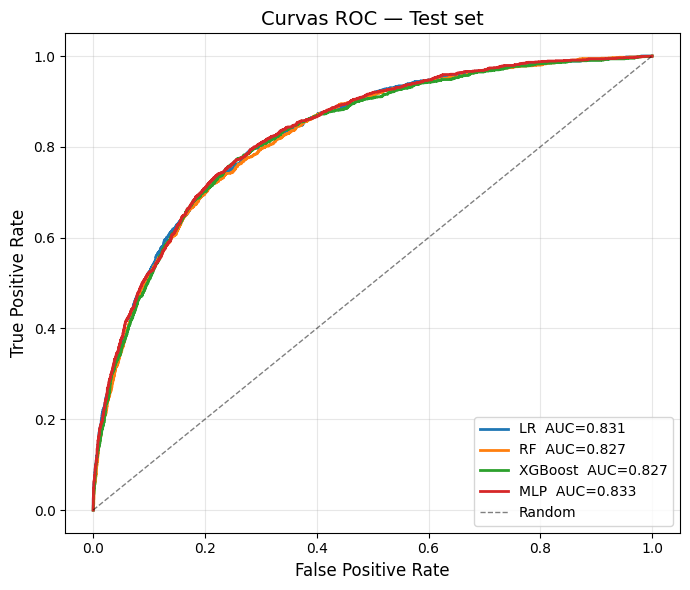

Guardado: outputs/figures/test_roc.png


In [7]:
COLORS = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"]

fig, ax = plt.subplots(figsize=(7, 6))
for (name, proba), color in zip(probas.items(), COLORS):
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    ax.plot(fpr, tpr, color=color, lw=2, label=f"{name}  AUC={auc:.3f}")
ax.plot([0, 1], [0, 1], "k--", lw=1, alpha=0.5, label="Random")
ax.set_xlabel("False Positive Rate", fontsize=12)
ax.set_ylabel("True Positive Rate", fontsize=12)
ax.set_title("Curvas ROC — Test set", fontsize=14)
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(str(FIGS_DIR / "test_roc.png"), dpi=150, bbox_inches="tight")
plt.show()
print("Guardado: outputs/figures/test_roc.png")

## 05 · Espacio Precisión-Recall

*(Diapositiva 4 — · marca el punto de operación con el umbral de val)*

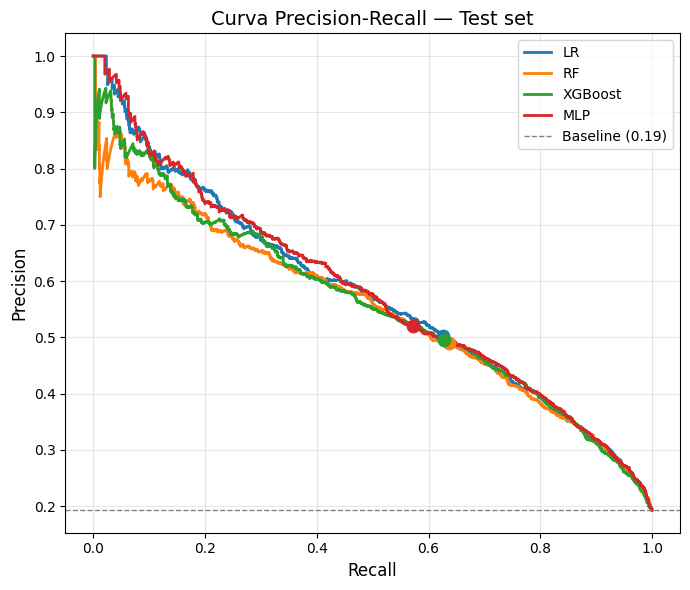

Guardado: outputs/figures/test_pr.png


In [8]:
fig, ax = plt.subplots(figsize=(7, 6))
for (name, proba), color in zip(probas.items(), COLORS):
    prec_c, rec_c, _ = precision_recall_curve(y_test, proba)
    ax.plot(rec_c, prec_c, color=color, lw=2, label=name)
    preds = (proba >= thresholds[name]).astype(int)
    ax.scatter(
        recall_score(y_test, preds, zero_division=0),
        precision_score(y_test, preds, zero_division=0),
        color=color, s=80, zorder=5,
    )
ax.axhline(y_test.mean(), color="gray", lw=1, ls="--",
           label=f"Baseline ({y_test.mean():.2f})")
ax.set_xlabel("Recall", fontsize=12)
ax.set_ylabel("Precision", fontsize=12)
ax.set_title("Curva Precision-Recall — Test set", fontsize=14)
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(str(FIGS_DIR / "test_pr.png"), dpi=150, bbox_inches="tight")
plt.show()
print("Guardado: outputs/figures/test_pr.png")

## 06 · Comparativa de métricas (barras)

*(Diapositiva 5)*

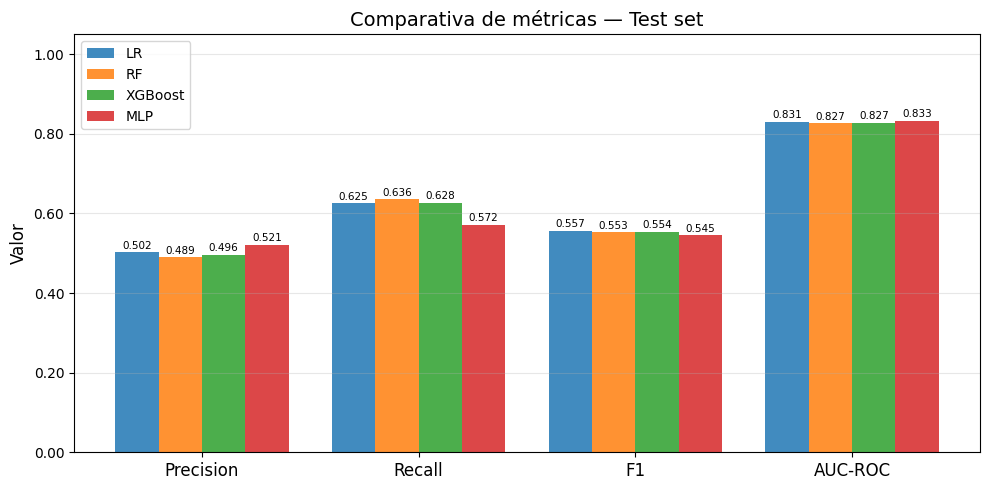

Guardado: outputs/figures/test_metrics_bar.png


In [9]:
metrics_cols = ["Precision", "Recall", "F1", "AUC-ROC"]
x     = np.arange(len(metrics_cols))
width = 0.2

fig, ax = plt.subplots(figsize=(10, 5))
for i, (name, color) in enumerate(zip(models.keys(), COLORS)):
    vals = [df.loc[name, m] for m in metrics_cols]
    bars = ax.bar(x + i * width, vals, width, label=name, color=color, alpha=0.85)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.004,
                f"{val:.3f}", ha="center", va="bottom", fontsize=7.5)
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(metrics_cols, fontsize=12)
ax.set_ylim(0, 1.05)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.2f"))
ax.set_ylabel("Valor", fontsize=12)
ax.set_title("Comparativa de métricas — Test set", fontsize=14)
ax.legend(fontsize=10)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(str(FIGS_DIR / "test_metrics_bar.png"), dpi=150, bbox_inches="tight")
plt.show()
print("Guardado: outputs/figures/test_metrics_bar.png")

## 07 · Matriz de confusión — mejor modelo (F1)

*(Diapositiva 5)*

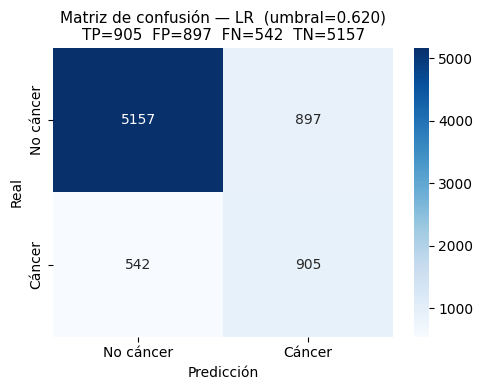

Guardado: outputs/figures/test_confusion_best.png
Sensibilidad (Recall): 0.6254
Especificidad:         0.8518
Falsos negativos:      542  (cánceres no detectados)


In [10]:
best_preds = (probas[best] >= thresholds[best]).astype(int)
cm = confusion_matrix(y_test, best_preds)
tn, fp, fn, tp = cm.ravel()

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues", ax=ax,
    xticklabels=["No cáncer", "Cáncer"],
    yticklabels=["No cáncer", "Cáncer"],
)
ax.set_title(
    f"Matriz de confusión — {best}  (umbral={thresholds[best]:.3f})\n"
    f"TP={tp}  FP={fp}  FN={fn}  TN={tn}",
    fontsize=11,
)
ax.set_xlabel("Predicción")
ax.set_ylabel("Real")
plt.tight_layout()
plt.savefig(str(FIGS_DIR / "test_confusion_best.png"), dpi=150, bbox_inches="tight")
plt.show()
print("Guardado: outputs/figures/test_confusion_best.png")
print(f"Sensibilidad (Recall): {tp/(tp+fn):.4f}")
print(f"Especificidad:         {tn/(tn+fp):.4f}")
print(f"Falsos negativos:      {fn}  (cánceres no detectados)")

## 08 · Conclusiones clínicas

### Rendimiento global

Los 4 modelos alcanzan un **AUC-ROC ≥ 0.82** en el conjunto de test independiente,
con un F1 ≈ 0.55 y un **Recall > 0.57**. El Recall elevado es prioritario en
cribado oncológico: minimizar falsos negativos (cánceres no detectados) importa
más que minimizar falsos positivos.

### Variables con mayor señal predictiva

| Variable | Efecto | Evidencia |
|---|---|---|
| `mut_BRCA1` | Positivo fuerte (≈ 3.9×) | Primer factor en LR, RF y XGBoost |
| `obesidad` | Positivo alto (≈ +24 pp) | Segundo factor consistente |
| `mut_TP53` | Positivo moderado | Coherente con oncología clínica |
| `fumador` | Positivo moderado | Coherente con epidemiología |
| `edad` | Positivo gradual | Riesgo acumulado con la edad |

### Variables bioquímicas

Las variables bioquímicas (`hemoglobina`, `plaquetas`, `creatinina`, etc.)
presentan señal inferior al 2% de variación media en la predicción.
Son variables de soporte, no drivers de predicción en este dataset.

### Exclusión de `mut_ALK`

> La guía del metadata sugería incluir `mut_ALK`, pero el análisis empírico
> mostró un lift de −0.03 pp (ratio 0.99×), por lo que se excluyó.
> **La evidencia observada prevalece sobre la guía teórica.**

### Modelo recomendado

La **Regresión Logística** obtiene el mejor F1 en test con el mayor AUC-ROC
conjunto. El **MLP** es competitivo y captura interacciones no lineales, pero
la LR ofrece mayor interpretabilidad clínica con rendimiento equivalente.